<a href="https://colab.research.google.com/github/sulucay01/DI725-assignment1/blob/dev/notebooks/04_modeling_fusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04_modeling_fusion.ipynb

This notebook builds a RoBERTa-based fusion model for customer sentiment classification.

Compared with the baseline text-only notebook, this model combines:

- text input from `clean_text`
- categorical features:
  - `issue_area`
  - `issue_category`

The notebook follows the same text-processing pipeline used in the baseline modeling notebook:

- `roberta-base`
- custom special tokens
- tail truncation
- `max_length = 512`
- train-only oversampling of the positive class (`x3`)

The goal is to test whether adding structured categorical information improves sentiment classification, especially for the minority positive class.

#### Imports

In [1]:
# !pip install transformers datasets scikit-learn wandb

import os
import re
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import wandb
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, classification_report, confusion_matrix
from transformers import (
    AutoTokenizer, AutoModel, TrainingArguments, Trainer,
    DataCollatorWithPadding, set_seed, EarlyStoppingCallback
)
from torch.utils.data import Dataset

In [2]:
# --- Configurations ---
SEED = 42
MODEL_NAME = "roberta-base"
BEST_MAX_LENGTH = 512
OVERSAMPLE_FACTOR = 3
SPECIAL_TOKENS = ["[CUSTOMER]", "[AGENT]", "[EMAIL]", "[PHONE]", "[ID]"]
WANDB_PROJECT = "customer_sentiment_fusion"
RUN_NAME = f"text_categorical_unfrozen_seed{SEED}"

In [3]:
def reset_all_seeds(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    set_seed(seed)

    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass

    if torch.cuda.is_available():
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32 = False

reset_all_seeds(SEED)

print("Seed set to:", SEED)
print("CUDA available:", torch.cuda.is_available())

Seed set to: 42
CUDA available: True


#### Data Loading & Categorical Encoding

In [4]:
from sklearn.preprocessing import LabelEncoder

# --- 1. Data Loading ---
train_df = pd.read_csv("https://raw.githubusercontent.com/sulucay01/DI725-assignment1/dev/data/processed/train_processed.csv")
val_df = pd.read_csv("https://raw.githubusercontent.com/sulucay01/DI725-assignment1/dev/data/processed/val_processed.csv")
test_df = pd.read_csv("https://raw.githubusercontent.com/sulucay01/DI725-assignment1/dev/data/processed/test_processed.csv")

for df in [train_df, val_df, test_df]:
    df["clean_text"] = df["clean_text"].fillna("").astype(str)
    # Standardize categories
    df["issue_area"] = df["issue_area"].fillna("unknown").astype(str).str.strip().str.lower()
    df["issue_category"] = df["issue_category"].fillna("unknown").astype(str).str.strip().str.lower()

In [5]:
# --- 2. Categorical Encoding ---
area_encoder = LabelEncoder()
category_encoder = LabelEncoder()

# Fit on train + explicitly include "unknown" to prevent errors on unseen data
area_encoder.fit(pd.concat([train_df["issue_area"], pd.Series(["unknown"])]).unique())
category_encoder.fit(pd.concat([train_df["issue_category"], pd.Series(["unknown"])]).unique())

def safe_encode(series, encoder):
    known_classes = set(encoder.classes_)
    safe_series = series.apply(lambda x: x if x in known_classes else "unknown")
    return encoder.transform(safe_series)

for df in [train_df, val_df, test_df]:
    df["issue_area_id"] = safe_encode(df["issue_area"], area_encoder)
    df["issue_category_id"] = safe_encode(df["issue_category"], category_encoder)

NUM_ISSUE_AREAS = len(area_encoder.classes_)
NUM_ISSUE_CATEGORIES = len(category_encoder.classes_)

print(f"Unique Issue Areas: {NUM_ISSUE_AREAS}")
print(f"Unique Issue Categories: {NUM_ISSUE_CATEGORIES}")

Unique Issue Areas: 7
Unique Issue Categories: 41


#### Oversampling & Tokenization

In [6]:
# --- 1. Oversampling ---
positive_label_id = train_df.loc[train_df["customer_sentiment"].str.lower() == "positive", "label"].iloc[0]

train_majority = train_df[train_df["label"] != positive_label_id].copy()
train_positive = train_df[train_df["label"] == positive_label_id].copy()

train_pos_os = resample(train_positive, replace=True, n_samples=len(train_positive) * OVERSAMPLE_FACTOR, random_state=SEED)
train_os = pd.concat([train_majority, train_pos_os], axis=0).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Original Positive Samples: {len(train_positive)} | Oversampled: {len(train_pos_os)}")

# --- 2. Tokenization ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
tokenizer.add_special_tokens({"additional_special_tokens": SPECIAL_TOKENS})

def truncate_text(text, tokenizer, max_length):
    token_ids = tokenizer.encode(text, add_special_tokens=False)
    budget = max_length - 2
    if len(token_ids) <= budget: return text
    return tokenizer.decode(token_ids[-budget:], skip_special_tokens=False, clean_up_tokenization_spaces=True)

for df in [train_os, val_df, test_df]:
    df["model_text"] = df["clean_text"].apply(lambda x: truncate_text(x, tokenizer, BEST_MAX_LENGTH))

train_encodings = tokenizer(train_os["model_text"].tolist(), truncation=True, max_length=BEST_MAX_LENGTH, padding=False)
val_encodings = tokenizer(val_df["model_text"].tolist(), truncation=True, max_length=BEST_MAX_LENGTH, padding=False)
test_encodings = tokenizer(test_df["model_text"].tolist(), truncation=True, max_length=BEST_MAX_LENGTH, padding=False)

Original Positive Samples: 14 | Oversampled: 42


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Token indices sequence length is longer than the specified maximum sequence length for this model (523 > 512). Running this sequence through the model will result in indexing errors


#### Dataset & Collator

In [7]:
class CategoricalFusionDataset(Dataset):
    def __init__(self, encodings, issue_area_ids, issue_category_ids, labels):
        self.encodings = encodings
        self.issue_area_ids = issue_area_ids.tolist()
        self.issue_category_ids = issue_category_ids.tolist()
        self.labels = labels.tolist()

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "issue_area_ids": self.issue_area_ids[idx],
            "issue_category_ids": self.issue_category_ids[idx],
            "labels": self.labels[idx]
        }

train_dataset = CategoricalFusionDataset(train_encodings, train_os["issue_area_id"], train_os["issue_category_id"], train_os["label"])
val_dataset = CategoricalFusionDataset(val_encodings, val_df["issue_area_id"], val_df["issue_category_id"], val_df["label"])
test_dataset = CategoricalFusionDataset(test_encodings, test_df["issue_area_id"], test_df["issue_category_id"], test_df["label"])

class CategoricalFusionDataCollator:
    def __init__(self, tokenizer):
        self.base_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    def __call__(self, features):
        text_features = [{"input_ids": f["input_ids"], "attention_mask": f["attention_mask"]} for f in features]
        batch = self.base_collator(text_features)

        batch["issue_area_ids"] = torch.tensor([f["issue_area_ids"] for f in features], dtype=torch.long)
        batch["issue_category_ids"] = torch.tensor([f["issue_category_ids"] for f in features], dtype=torch.long)
        batch["labels"] = torch.tensor([f["labels"] for f in features], dtype=torch.long)
        return batch

#### Model Definition

In [8]:
class RobertaCategoricalFusionClassifier(nn.Module):
    def __init__(self, model_name, num_labels, num_areas, num_categories, class_weights, area_dim=16, category_dim=16, fusion_hidden_dim=256, dropout=0.2):
        super().__init__()
        self.text_encoder = AutoModel.from_pretrained(model_name)
        self.text_encoder.resize_token_embeddings(len(tokenizer))

        # Unfrozen text encoder!

        # Embeddings for categorical features
        self.area_embedding = nn.Embedding(num_embeddings=num_areas, embedding_dim=area_dim)
        self.category_embedding = nn.Embedding(num_embeddings=num_categories, embedding_dim=category_dim)

        fusion_input_dim = self.text_encoder.config.hidden_size + area_dim + category_dim

        self.fusion_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(fusion_input_dim, fusion_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden_dim, num_labels)
        )
        self.class_weights = class_weights

    def forward(self, input_ids=None, attention_mask=None, issue_area_ids=None, issue_category_ids=None, labels=None):
        outputs = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_features = outputs.last_hidden_state[:, 0, :]

        area_features = self.area_embedding(issue_area_ids)
        category_features = self.category_embedding(issue_category_ids)

        # Concatenate: [Batch, 768] + [Batch, 16] + [Batch, 16] = [Batch, 800]
        fused_features = torch.cat([text_features, area_features, category_features], dim=1)
        logits = self.fusion_head(fused_features)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
            loss = loss_fct(logits, labels)

        return {"loss": loss, "logits": logits}

#### W&B Tracking & Training

In [9]:
# --- 1. Class Weights ---
class_labels = np.sort(train_df["label"].unique())
class_weights_np = compute_class_weight(class_weight="balanced", classes=class_labels, y=train_df["label"].values)
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float)

model = RobertaCategoricalFusionClassifier(
    model_name=MODEL_NAME,
    num_labels=len(class_labels),
    num_areas=NUM_ISSUE_AREAS,
    num_categories=NUM_ISSUE_CATEGORIES,
    class_weights=class_weights_tensor
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted")
    }

# --- 2. W&B Integration ---
wandb.login()
wandb.init(
    project=WANDB_PROJECT,
    name=RUN_NAME,
    config={
        "model": MODEL_NAME,
        "max_length": BEST_MAX_LENGTH,
        "oversample_factor": OVERSAMPLE_FACTOR,
        "fusion_type": "text + categorical",
        "epochs": 3
    }
)

training_args = TrainingArguments(
    output_dir=f"./outputs/{RUN_NAME}",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=20,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=3,          # Cap at 3 epochs based on previous success
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="wandb",           # W&B Hook
    fp16=torch.cuda.is_available(),
    seed=SEED
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=CategoricalFusionDataCollator(tokenizer=tokenizer),
    compute_metrics=compute_metrics
)

print("\nStarting Training...")
trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, 

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



Starting Training...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.924963,0.858690,0.690722,0.460012,0.684875
2,0.602818,0.620579,0.706186,0.551619,0.750152
3,0.553152,0.495652,0.804124,0.597553,0.826467


TrainOutput(global_step=303, training_loss=0.8042089112914435, metrics={'train_runtime': 25.9821, 'train_samples_per_second': 92.487, 'train_steps_per_second': 11.662, 'total_flos': 0.0, 'train_loss': 0.8042089112914435, 'epoch': 3.0})

#### Final Evaluation

In [10]:
def evaluate_and_print_cm(trainer, dataset, split_name, label_names):
    print(f"\nGenerating predictions for {split_name.upper()}...")
    predictions = trainer.predict(dataset)
    y_pred = np.argmax(predictions.predictions, axis=1)
    y_true = predictions.label_ids

    print(f"\n===== {split_name.upper()} CLASSIFICATION REPORT =====")
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))
    print(f"\n===== {split_name.upper()} CONFUSION MATRIX =====")
    print(confusion_matrix(y_true, y_pred))

label_map_df = train_df[["customer_sentiment", "label"]].drop_duplicates().sort_values("label")
label_names = label_map_df["customer_sentiment"].tolist()

print("\n" + "="*50 + "\nFINAL EVALUATION\n" + "="*50)
evaluate_and_print_cm(trainer, train_dataset, "train", label_names)
evaluate_and_print_cm(trainer, val_dataset, "val", label_names)
evaluate_and_print_cm(trainer, test_dataset, "test", label_names)

wandb.finish()


FINAL EVALUATION

Generating predictions for TRAIN...



===== TRAIN CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    negative       0.89      0.88      0.88       326
     neutral       0.88      0.79      0.83       433
    positive       0.39      0.88      0.54        42

    accuracy                           0.83       801
   macro avg       0.72      0.85      0.75       801
weighted avg       0.86      0.83      0.84       801


===== TRAIN CONFUSION MATRIX =====
[[286  40   0]
 [ 35 341  57]
 [  0   5  37]]

Generating predictions for VAL...



===== VAL CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    negative       0.88      0.84      0.86        82
     neutral       0.85      0.79      0.82       109
    positive       0.07      0.33      0.11         3

    accuracy                           0.80       194
   macro avg       0.60      0.65      0.60       194
weighted avg       0.85      0.80      0.83       194


===== VAL CONFUSION MATRIX =====
[[69 13  0]
 [ 9 86 14]
 [ 0  2  1]]

Generating predictions for TEST...



===== TEST CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    negative       1.00      0.80      0.89        10
     neutral       0.71      1.00      0.83        10
    positive       1.00      0.80      0.89        10

    accuracy                           0.87        30
   macro avg       0.90      0.87      0.87        30
weighted avg       0.90      0.87      0.87        30


===== TEST CONFUSION MATRIX =====
[[ 8  2  0]
 [ 0 10  0]
 [ 0  2  8]]


eval/accuracy,▁▂█
eval/loss,█▃▁
eval/macro_f1,▁▆█
eval/runtime,█▇▁
eval/samples_per_second,▁▂█
eval/steps_per_second,▁▂█
eval/weighted_f1,▁▄█
test/accuracy,▄▁█
test/loss,▁▆█
test/macro_f1,▅▁█
+9,...


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
num_added = tokenizer.add_special_tokens(
    {"additional_special_tokens": SPECIAL_TOKENS}
)

print("Added special tokens:", num_added)
print("Tokenizer size:", len(tokenizer))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Added special tokens: 5
Tokenizer size: 50270


In [ ]:
def truncate_text(text, tokenizer, max_length, strategy="tail"):
    if not isinstance(text, str):
        text = ""

    token_ids = tokenizer.encode(text, add_special_tokens=False)
    token_budget = max_length - 2  # reserve space for <s> and </s>

    if len(token_ids) <= token_budget:
        return text

    if strategy == "head":
        kept_ids = token_ids[:token_budget]
    elif strategy == "tail":
        kept_ids = token_ids[-token_budget:]
    elif strategy == "head_tail":
        head_size = token_budget // 2
        tail_size = token_budget - head_size
        kept_ids = token_ids[:head_size] + token_ids[-tail_size:]
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    return tokenizer.decode(
        kept_ids,
        skip_special_tokens=False,
        clean_up_tokenization_spaces=True
    )


def apply_truncation(df, strategy, tokenizer, max_length):
    out = df.copy()
    out["model_text"] = out[TEXT_COL].apply(
        lambda x: truncate_text(x, tokenizer, max_length, strategy=strategy)
    )
    return out

In [ ]:
train_base = apply_truncation(
    train_df,
    BEST_TRUNCATION_STRATEGY,
    tokenizer,
    BEST_MAX_LENGTH
)

val_base = apply_truncation(
    val_df,
    BEST_TRUNCATION_STRATEGY,
    tokenizer,
    BEST_MAX_LENGTH
)

test_base = apply_truncation(
    test_df,
    BEST_TRUNCATION_STRATEGY,
    tokenizer,
    BEST_MAX_LENGTH
)

Token indices sequence length is longer than the specified maximum sequence length for this model (514 > 512). Running this sequence through the model will result in indexing errors


In [ ]:
print(train_base[["clean_text", "model_text"]].head(2))

                                                                                                                                                                                                clean_text  \
0  [AGENT] Hello, thank you for contacting BrownBox customer support. My name is Jane, how may I assist you today?\n[CUSTOMER] Hi Jane, I placed an order for a power bank a week ago, and I still have...   
1  [CUSTOMER] Hi, I need help with returning a toy I purchased from BrownBox.\n[AGENT] Hi there, I'm happy to assist you with that. May I have your name and order number, please?\n[CUSTOMER] Sure, my...   

                                                                                                                                                                                                model_text  
0   you for contacting BrownBox customer support. My name is Jane, how may I assist you today?\n[CUSTOMER] Hi Jane, I placed an order for a power bank a week ago, and I still h

In [ ]:
def get_token_lengths(texts, tokenizer):
    lengths = []
    for text in texts:
        enc = tokenizer(
            text,
            add_special_tokens=True,
            truncation=False,
            padding=False
        )
        lengths.append(len(enc["input_ids"]))
    return lengths

train_model_lengths = get_token_lengths(train_base["model_text"].tolist(), tokenizer)
val_model_lengths = get_token_lengths(val_base["model_text"].tolist(), tokenizer)
test_model_lengths = get_token_lengths(test_base["model_text"].tolist(), tokenizer)

print("Train max token length after truncation:", max(train_model_lengths))
print("Val max token length after truncation:", max(val_model_lengths))
print("Test max token length after truncation:", max(test_model_lengths))

Train max token length after truncation: 512
Val max token length after truncation: 512
Test max token length after truncation: 512


In [ ]:
def summarize_lengths(lengths, split_name):
    arr = np.array(lengths)

    print(f"\n===== {split_name.upper()} TOKEN LENGTH SUMMARY =====")
    print(f"count:   {len(arr)}")
    print(f"min:     {arr.min()}")
    print(f"mean:    {arr.mean():.2f}")
    print(f"median:  {np.median(arr):.2f}")
    print(f"p90:     {np.percentile(arr, 90):.2f}")
    print(f"p95:     {np.percentile(arr, 95):.2f}")
    print(f"p99:     {np.percentile(arr, 99):.2f}")
    print(f"max:     {arr.max()}")

summarize_lengths(train_model_lengths, "train")
summarize_lengths(val_model_lengths, "val")
summarize_lengths(test_model_lengths, "test")


===== TRAIN TOKEN LENGTH SUMMARY =====
count:   773
min:     170
mean:    444.08
median:  460.00
p90:     512.00
p95:     512.00
p99:     512.00
max:     512

===== VAL TOKEN LENGTH SUMMARY =====
count:   194
min:     227
mean:    445.60
median:  447.00
p90:     512.00
p95:     512.00
p99:     512.00
max:     512

===== TEST TOKEN LENGTH SUMMARY =====
count:   30
min:     256
mean:    438.13
median:  466.00
p90:     512.00
p95:     512.00
p99:     512.00
max:     512


In [ ]:
def safe_div(a, b):
    return a / b if b != 0 else 0.0


def split_turns(text):
    """
    Split conversation into speaker turns using [CUSTOMER] and [AGENT].
    Returns a list of tuples: (speaker, utterance)
    """
    if not isinstance(text, str):
        return []

    pattern = r"(\[CUSTOMER\]|\[AGENT\])"
    parts = re.split(pattern, text)

    turns = []
    current_speaker = None

    for part in parts:
        part = part.strip()
        if not part:
            continue

        if part in ["[CUSTOMER]", "[AGENT]"]:
            current_speaker = part
        else:
            if current_speaker is not None:
                turns.append((current_speaker, part))

    return turns

In [ ]:
def extract_numeric_features(df, text_col="model_text"):
    out = df.copy()
    text_series = out[text_col].fillna("").astype(str)

    # basic text size
    out["num_lines"] = text_series.apply(
        lambda x: len([line for line in x.split("\n") if line.strip() != ""])
    )
    out["num_words"] = text_series.apply(lambda x: len(x.split()))
    out["num_chars"] = text_series.str.len()
    out["avg_word_len"] = text_series.apply(
        lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0.0
    )

    # punctuation / style
    out["question_mark_count"] = text_series.str.count(r"\?")
    out["exclamation_count"] = text_series.str.count(r"!")
    out["digit_count"] = text_series.str.count(r"\d")

    # special token counts
    out["email_token_count"] = text_series.apply(lambda x: x.count("[EMAIL]"))
    out["phone_token_count"] = text_series.apply(lambda x: x.count("[PHONE]"))
    out["id_token_count"] = text_series.apply(lambda x: x.count("[ID]"))
    out["customer_token_count"] = text_series.apply(lambda x: x.count("[CUSTOMER]"))
    out["agent_token_count"] = text_series.apply(lambda x: x.count("[AGENT]"))

    out["sensitive_token_total"] = (
        out["email_token_count"] +
        out["phone_token_count"] +
        out["id_token_count"]
    )
    out["sensitive_token_ratio"] = out.apply(
        lambda row: safe_div(row["sensitive_token_total"], row["num_words"]),
        axis=1
    )

    # turn-based features
    turns_all = text_series.apply(split_turns)

    out["total_turn_count"] = turns_all.apply(len)
    out["customer_turn_count"] = turns_all.apply(
        lambda turns: sum(1 for speaker, _ in turns if speaker == "[CUSTOMER]")
    )
    out["agent_turn_count"] = turns_all.apply(
        lambda turns: sum(1 for speaker, _ in turns if speaker == "[AGENT]")
    )

    out["customer_turn_ratio"] = out.apply(
        lambda row: safe_div(row["customer_turn_count"], row["total_turn_count"]),
        axis=1
    )
    out["agent_turn_ratio"] = out.apply(
        lambda row: safe_div(row["agent_turn_count"], row["total_turn_count"]),
        axis=1
    )
    out["turn_count_diff"] = out["customer_turn_count"] - out["agent_turn_count"]

    # per-turn word stats
    def turn_word_lengths(turns):
        return [len(utt.split()) for _, utt in turns if utt.strip() != ""]

    turn_lengths = turns_all.apply(turn_word_lengths)

    out["avg_words_per_turn"] = turn_lengths.apply(
        lambda arr: float(np.mean(arr)) if len(arr) > 0 else 0.0
    )
    out["std_turn_len_words"] = turn_lengths.apply(
        lambda arr: float(np.std(arr)) if len(arr) > 0 else 0.0
    )
    out["max_words_in_turn"] = turn_lengths.apply(
        lambda arr: max(arr) if len(arr) > 0 else 0
    )
    out["min_words_in_turn"] = turn_lengths.apply(
        lambda arr: min(arr) if len(arr) > 0 else 0
    )

    # customer / agent text volume
    def speaker_word_count(turns, target_speaker):
        return sum(len(utt.split()) for speaker, utt in turns if speaker == target_speaker)

    def speaker_char_count(turns, target_speaker):
        return sum(len(utt) for speaker, utt in turns if speaker == target_speaker)

    out["customer_word_count"] = turns_all.apply(
        lambda turns: speaker_word_count(turns, "[CUSTOMER]")
    )
    out["agent_word_count"] = turns_all.apply(
        lambda turns: speaker_word_count(turns, "[AGENT]")
    )
    out["customer_char_count"] = turns_all.apply(
        lambda turns: speaker_char_count(turns, "[CUSTOMER]")
    )
    out["agent_char_count"] = turns_all.apply(
        lambda turns: speaker_char_count(turns, "[AGENT]")
    )

    out["customer_to_agent_word_ratio"] = out.apply(
        lambda row: safe_div(row["customer_word_count"], row["agent_word_count"]),
        axis=1
    )
    out["customer_to_agent_char_ratio"] = out.apply(
        lambda row: safe_div(row["customer_char_count"], row["agent_char_count"]),
        axis=1
    )

    out["avg_words_per_customer_turn"] = out.apply(
        lambda row: safe_div(row["customer_word_count"], row["customer_turn_count"]),
        axis=1
    )
    out["avg_words_per_agent_turn"] = out.apply(
        lambda row: safe_div(row["agent_word_count"], row["agent_turn_count"]),
        axis=1
    )

    # ending features
    out["ends_with_customer"] = turns_all.apply(
        lambda turns: 1 if len(turns) > 0 and turns[-1][0] == "[CUSTOMER]" else 0
    )
    out["ends_with_agent"] = turns_all.apply(
        lambda turns: 1 if len(turns) > 0 and turns[-1][0] == "[AGENT]" else 0
    )
    out["last_turn_word_count"] = turns_all.apply(
        lambda turns: len(turns[-1][1].split()) if len(turns) > 0 else 0
    )

    # lexical diversity
    out["unique_word_count"] = text_series.apply(
        lambda x: len(set(x.split()))
    )
    out["lexical_diversity"] = out.apply(
        lambda row: safe_div(row["unique_word_count"], row["num_words"]),
        axis=1
    )

    return out

In [ ]:
NUMERIC_COLS = [
    "num_lines",
    "num_words",
    "num_chars",
    "avg_word_len",
    "question_mark_count",
    "exclamation_count",
    "digit_count",
    "email_token_count",
    "phone_token_count",
    "id_token_count",
    "customer_token_count",
    "agent_token_count",
    "sensitive_token_total",
    "sensitive_token_ratio",
    "total_turn_count",
    "customer_turn_count",
    "agent_turn_count",
    "customer_turn_ratio",
    "agent_turn_ratio",
    "turn_count_diff",
    "avg_words_per_turn",
    "std_turn_len_words",
    "max_words_in_turn",
    "min_words_in_turn",
    "customer_word_count",
    "agent_word_count",
    "customer_char_count",
    "agent_char_count",
    "customer_to_agent_word_ratio",
    "customer_to_agent_char_ratio",
    "avg_words_per_customer_turn",
    "avg_words_per_agent_turn",
    "ends_with_customer",
    "ends_with_agent",
    "last_turn_word_count",
    "unique_word_count",
    "lexical_diversity",
]

In [ ]:
train_feat = extract_numeric_features(train_base, text_col="model_text")
val_feat = extract_numeric_features(val_base, text_col="model_text")
test_feat = extract_numeric_features(test_base, text_col="model_text")

In [ ]:
train_feat[["customer_sentiment"] + NUMERIC_COLS[:10]].head()

,customer_sentiment,num_lines,num_words,num_chars,avg_word_len,question_mark_count,exclamation_count,digit_count,email_token_count,phone_token_count,id_token_count
0,negative,17,416,2266,4.447115,8,2,2,1,0,1
1,neutral,22,359,2100,4.852368,6,0,4,0,0,0
2,negative,21,387,2212,4.715762,6,1,6,0,0,0
3,neutral,16,373,2123,4.694370,4,3,2,0,0,1
4,neutral,19,350,1947,4.565714,4,3,2,0,0,0


In [ ]:
feature_quality_df = pd.DataFrame({
    "feature": NUMERIC_COLS,
    "dtype": [train_feat[col].dtype for col in NUMERIC_COLS],
    "missing_train": [train_feat[col].isna().sum() for col in NUMERIC_COLS],
    "missing_val": [val_feat[col].isna().sum() for col in NUMERIC_COLS],
    "missing_test": [test_feat[col].isna().sum() for col in NUMERIC_COLS],
    "train_min": [train_feat[col].min() for col in NUMERIC_COLS],
    "train_max": [train_feat[col].max() for col in NUMERIC_COLS],
})

feature_quality_df

,feature,dtype,missing_train,missing_val,missing_test,train_min,train_max
0,num_lines,int64,0,0,0,7.000000,29.000000
1,num_words,int64,0,0,0,129.000000,426.000000
2,num_chars,int64,0,0,0,745.000000,2468.000000
3,avg_word_len,float64,0,0,0,4.293103,5.135870
4,question_mark_count,int64,0,0,0,2.000000,10.000000
5,exclamation_count,int64,0,0,0,0.000000,8.000000
6,digit_count,int64,0,0,0,0.000000,51.000000
7,email_token_count,int64,0,0,0,0.000000,4.000000
8,phone_token_count,int64,0,0,0,0.000000,2.000000
9,id_token_count,int64,0,0,0,0.000000,8.000000


In [ ]:
summary_stats = (
    train_feat
    .groupby("customer_sentiment")[NUMERIC_COLS]
    .agg(["mean", "median", "std"])
    .round(3)
)

summary_stats

num_lines               num_words                num_chars  \
                        mean median    std      mean median     std      mean   
customer_sentiment                                                              
negative              18.491   19.0  2.959   375.914  391.0  38.102  2152.209   
neutral               16.612   17.0  3.327   324.776  328.0  58.159  1859.266   
positive              16.071   15.5  2.093   291.929  279.0  52.094  1684.857   

                                    avg_word_len                \
                    median      std         mean median    std   
customer_sentiment                                               
negative            2234.5  216.007        4.729  4.727  0.126   
neutral             1888.0  336.470        4.727  4.716  0.127   
positive            1615.5  312.944        4.768  4.773  0.127   

                   question_mark_count               exclamation_count         \
                                  mean median    std              mean median   
customer_sentiment                                                              
negative                         6.175    6.0  1.591             1.819    1.0   
neutral                          5.919    6.0  1.538             2.307    2.0   
positive                         5.286    4.0  2.091             2.857    2.5   

                          digit_count               email_token_count         \
                      std        mean median    std              mean median   
customer_sentiment                                                             
negative            1.530       3.736    3.0  3.982             0.316    0.0   
neutral             1.514       3.762    2.0  4.999             0.402    0.0   
positive            2.070       3.071    2.0  3.149             0.214    0.0   

                          phone_token_count               id_token_count  \
                      std              mean median    std           mean   
customer_sentiment                                                         
negative            0.528             0.083    0.0  0.308          0.475   
neutral             0.624             0.095    0.0  0.316          0.469   
positive            0.426             0.000    0.0  0.000          0.571   

                                 customer_token_count                \
                   median    std                 mean median    std   
customer_sentiment                                                    
negative              0.0  0.616                7.816    8.0  1.400   
neutral               0.0  0.700                7.309    7.0  1.483   
positive              1.0  0.514                6.714    6.0  1.326   

                   agent_token_count               sensitive_token_total  \
                                mean median    std                  mean   
customer_sentiment                                                         
negative                       8.494    9.0  2.242                 0.874   
neutral                        8.236    8.0  1.761                 0.965   
positive                       8.214    8.0  0.975                 0.786   

                                 sensitive_token_ratio                \
                   median    std                  mean median    std   
customer_sentiment                                                     
negative              1.0  0.898                 0.002  0.002  0.002   
neutral               1.0  0.968                 0.003  0.003  0.003   
positive              1.0  0.699                 0.003  0.003  0.003   

                   total_turn_count               customer_turn_count         \
                               mean median    std                mean median   
customer_sentiment                                                             
negative                     16.310   16.0  3.118               7.816    8.0   
neutral                      15.545   15.0  2.929               7.309    

In [ ]:
class_means = (
    train_feat
    .groupby("customer_sentiment")[NUMERIC_COLS]
    .mean()
    .T
    .reset_index()
    .rename(columns={"index": "feature"})
)

class_means["range_across_classes"] = (
    class_means[["negative", "neutral", "positive"]].max(axis=1) -
    class_means[["negative", "neutral", "positive"]].min(axis=1)
)

class_means = class_means.sort_values(
    "range_across_classes",
    ascending=False
).reset_index(drop=True)

class_means.head(20)

customer_sentiment,feature,negative,neutral,positive,range_across_classes
0,num_chars,2152.208589,1859.265589,1684.857143,467.351446
1,agent_char_count,1357.941718,1191.676674,1120.142857,237.798861
2,customer_char_count,582.328221,492.337182,406.357143,175.971078
3,num_words,375.914110,324.775982,291.928571,83.985539
4,agent_word_count,244.021472,214.080831,200.285714,43.735758
5,customer_word_count,107.843558,92.563510,75.785714,32.057844
6,unique_word_count,179.202454,164.154734,159.571429,19.631025
7,max_words_in_turn,52.021472,50.556582,44.571429,7.450044
8,avg_words_per_agent_turn,29.816662,26.511865,24.309580,5.507082
9,avg_words_per_turn,22.574824,20.145233,18.480769,4.094055


In [ ]:
feature_ranking_rows = []

for col in NUMERIC_COLS:
    overall_std = train_feat[col].std()
    means = train_feat.groupby("customer_sentiment")[col].mean()

    if overall_std == 0 or pd.isna(overall_std):
        score = 0.0
    else:
        score = (means.max() - means.min()) / overall_std

    feature_ranking_rows.append({
        "feature": col,
        "negative_mean": means.get("negative", np.nan),
        "neutral_mean": means.get("neutral", np.nan),
        "positive_mean": means.get("positive", np.nan),
        "overall_std": overall_std,
        "standardized_separation": score
    })

feature_ranking_df = pd.DataFrame(feature_ranking_rows)
feature_ranking_df = feature_ranking_df.sort_values(
    "standardized_separation",
    ascending=False
).reset_index(drop=True)

feature_ranking_df.head(20)

,feature,negative_mean,neutral_mean,positive_mean,overall_std,standardized_separation
0,num_words,375.914110,324.775982,291.928571,56.860431,1.477047
1,lexical_diversity,0.479329,0.511763,0.549307,0.048460,1.444045
2,num_chars,2152.208589,1859.265589,1684.857143,326.989276,1.429256
3,unique_word_count,179.202454,164.154734,159.571429,21.245543,0.924007
4,agent_word_count,244.021472,214.080831,200.285714,54.019065,0.809636
5,agent_char_count,1357.941718,1191.676674,1120.142857,302.106532,0.787136
6,avg_words_per_turn,22.574824,20.145233,18.480769,5.337600,0.767022
7,customer_turn_count,7.815951,7.309469,6.714286,1.469523,0.749675
8,customer_token_count,7.815951,7.309469,6.714286,1.469523,0.749675
9,avg_words_per_agent_turn,29.816662,26.511865,24.309580,7.416233,0.742571


<Figure size 800x400 with 0 Axes>

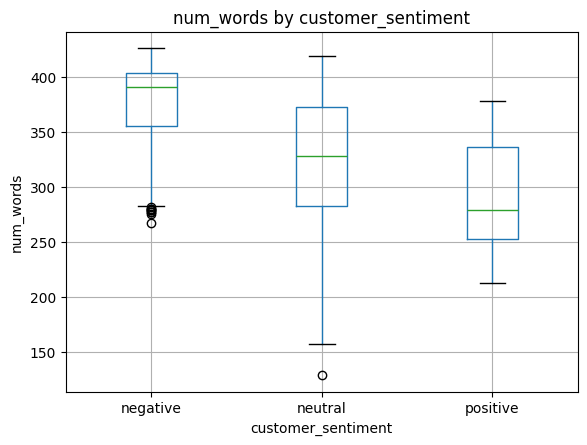

<Figure size 800x400 with 0 Axes>

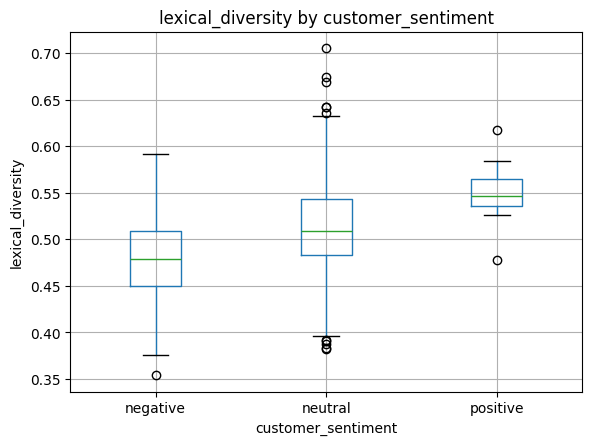

<Figure size 800x400 with 0 Axes>

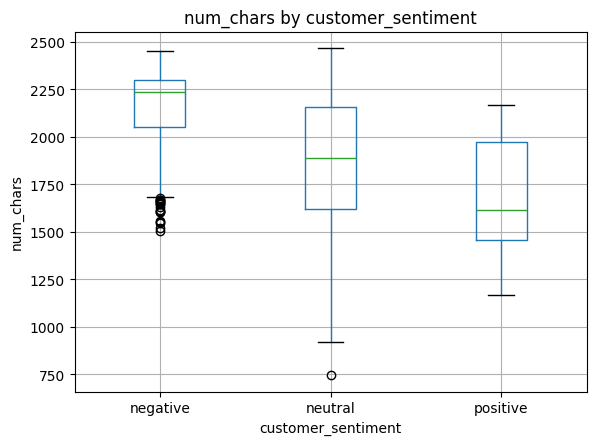

<Figure size 800x400 with 0 Axes>

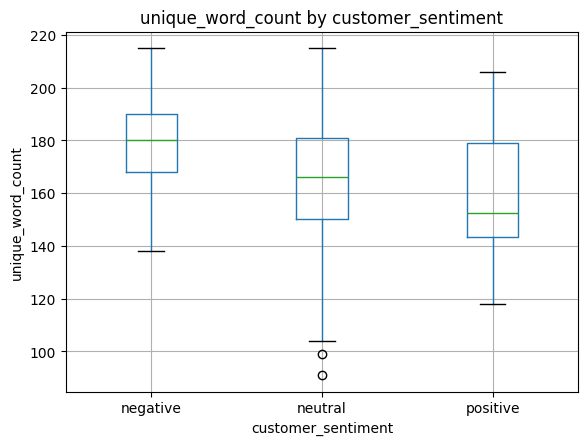

<Figure size 800x400 with 0 Axes>

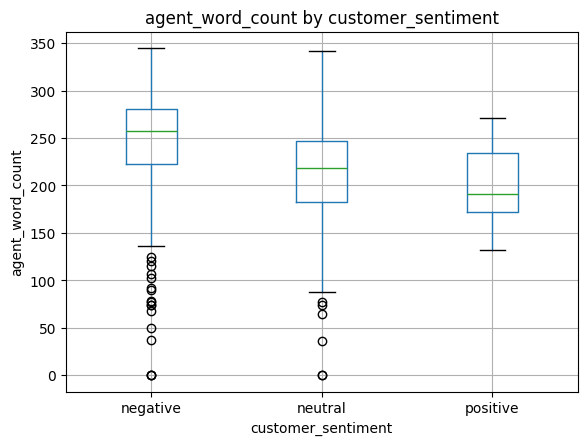

<Figure size 800x400 with 0 Axes>

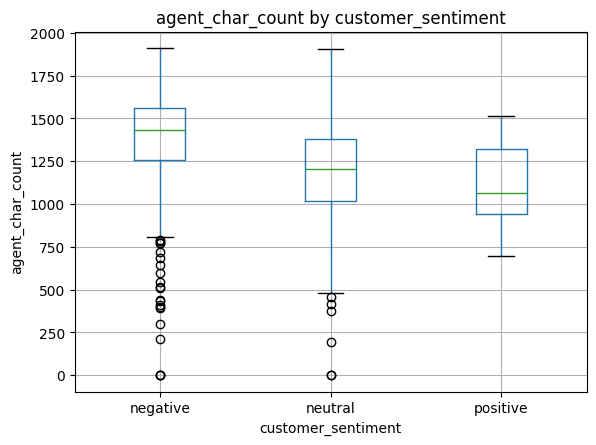

<Figure size 800x400 with 0 Axes>

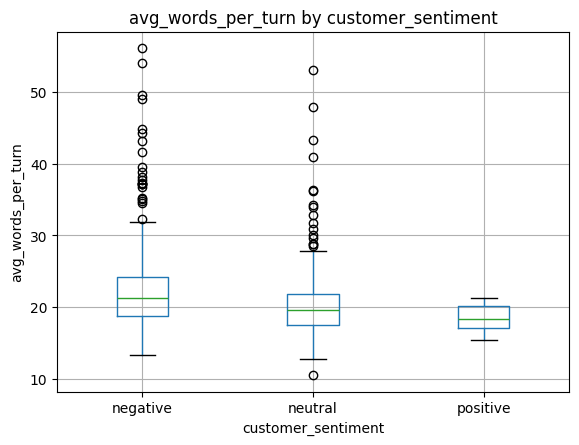

<Figure size 800x400 with 0 Axes>

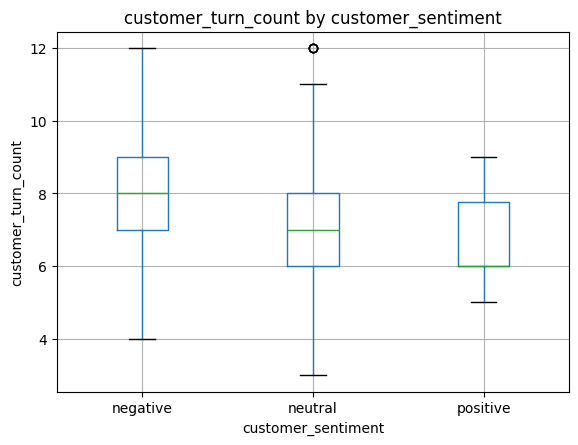

<Figure size 800x400 with 0 Axes>

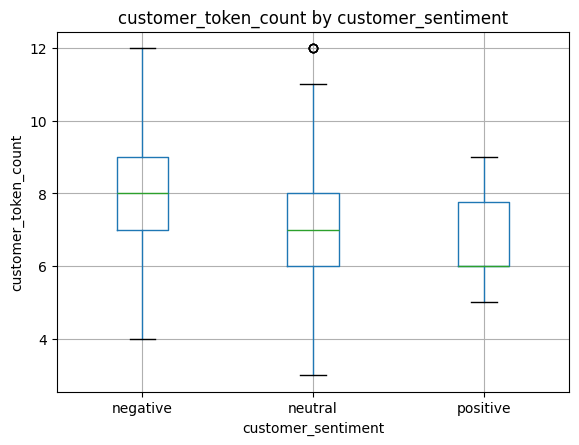

<Figure size 800x400 with 0 Axes>

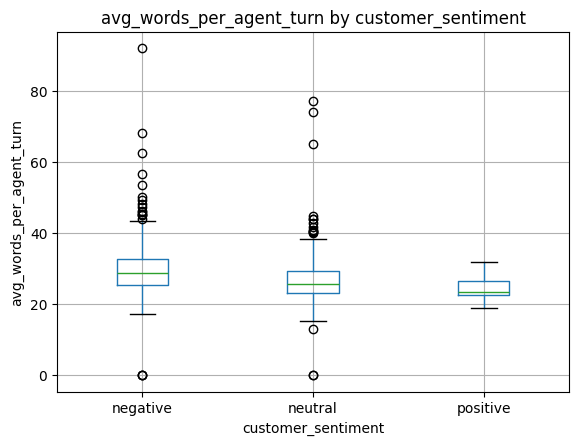

<Figure size 800x400 with 0 Axes>

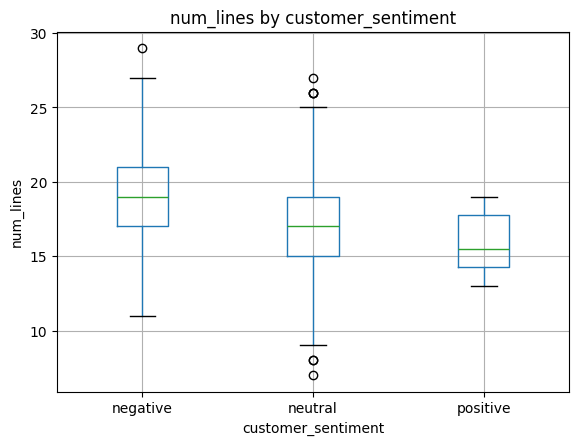

<Figure size 800x400 with 0 Axes>

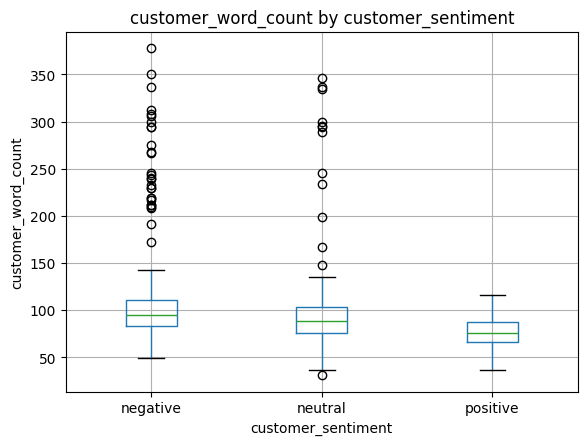

In [ ]:
top_features = feature_ranking_df["feature"].head(12).tolist()

for col in top_features:
    plt.figure(figsize=(8, 4))
    train_feat.boxplot(column=col, by="customer_sentiment")
    plt.title(f"{col} by customer_sentiment")
    plt.suptitle("")
    plt.xlabel("customer_sentiment")
    plt.ylabel(col)
    plt.show()

In [ ]:
feature_ranking_df.head(15)

,feature,negative_mean,neutral_mean,positive_mean,overall_std,standardized_separation
0,num_words,375.914110,324.775982,291.928571,56.860431,1.477047
1,lexical_diversity,0.479329,0.511763,0.549307,0.048460,1.444045
2,num_chars,2152.208589,1859.265589,1684.857143,326.989276,1.429256
3,unique_word_count,179.202454,164.154734,159.571429,21.245543,0.924007
4,agent_word_count,244.021472,214.080831,200.285714,54.019065,0.809636
5,agent_char_count,1357.941718,1191.676674,1120.142857,302.106532,0.787136
6,avg_words_per_turn,22.574824,20.145233,18.480769,5.337600,0.767022
7,customer_turn_count,7.815951,7.309469,6.714286,1.469523,0.749675
8,customer_token_count,7.815951,7.309469,6.714286,1.469523,0.749675
9,avg_words_per_agent_turn,29.816662,26.511865,24.309580,7.416233,0.742571


In [ ]:
NUMERIC_COLS = [
    "num_words",                     # strongest signal
    "lexical_diversity",            # unique signal (important!)
    "agent_word_count",             # agent effort
    "customer_word_count",          # customer effort
    "avg_words_per_turn",           # structure
    "customer_turn_count",          # interaction intensity
    "std_turn_len_words",           # variability
    "exclamation_count",            # positive signal
]

In [ ]:
from sklearn.utils import resample
label_map_df = (
    train_df[["customer_sentiment", "label"]]
    .drop_duplicates()
    .sort_values("label")
)

positive_label_id = label_map_df.loc[
    label_map_df["customer_sentiment"].str.lower() == "positive", "label"
].iloc[0]

OVERSAMPLE_FACTOR = 2

print("Original training label distribution:")
print(train_feat["label"].value_counts().sort_index())

train_majority_part = train_feat[train_feat["label"] != positive_label_id].copy()
train_positive_part = train_feat[train_feat["label"] == positive_label_id].copy()

reset_all_seeds(SEED)

train_positive_oversampled = resample(
    train_positive_part,
    replace=True,
    n_samples=len(train_positive_part) * OVERSAMPLE_FACTOR,
    random_state=SEED
)

train_feat_os = pd.concat(
    [train_majority_part, train_positive_oversampled],
    axis=0
).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("\nOversampled training label distribution:")
print(train_feat_os["label"].value_counts().sort_index())

Original training label distribution:
label
0    326
1    433
2     14
Name: count, dtype: int64

Oversampled training label distribution:
label
0    326
1    433
2     28
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_feat_os[NUMERIC_COLS] = scaler.fit_transform(train_feat_os[NUMERIC_COLS])
val_feat[NUMERIC_COLS] = scaler.transform(val_feat[NUMERIC_COLS])
test_feat[NUMERIC_COLS] = scaler.transform(test_feat[NUMERIC_COLS])

In [ ]:
train_feat[NUMERIC_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
num_words,773.0,345.747736,56.860431,129.000000,305.000000,358.000000,395.000000,426.000000
lexical_diversity,773.0,0.498764,0.048460,0.353960,0.465686,0.497462,0.528777,0.705426
agent_word_count,773.0,226.457956,54.019065,0.000000,196.000000,234.000000,267.000000,345.000000
customer_word_count,773.0,98.703752,43.758362,31.000000,78.000000,91.000000,106.000000,378.000000
avg_words_per_turn,773.0,21.139727,5.337600,10.476190,18.000000,20.307692,22.562500,56.166667
customer_turn_count,773.0,7.512290,1.469523,3.000000,7.000000,7.000000,8.000000,12.000000
std_turn_len_words,773.0,14.046134,4.008045,6.005076,11.529244,13.407894,15.656813,37.002534
exclamation_count,773.0,2.111255,1.551546,0.000000,1.000000,2.000000,3.000000,8.000000


In [ ]:
CAT_COLS = ["issue_area", "issue_category"]

cat_vocab_maps = {}
cat_num_classes = {}

for col in CAT_COLS:
    unique_values = sorted(
        train_feat_os[col].fillna("unknown").astype(str).unique().tolist()
    )

    vocab = {"[UNK]": 0}
    for idx, value in enumerate(unique_values, start=1):
        vocab[value] = idx

    cat_vocab_maps[col] = vocab
    cat_num_classes[col] = len(vocab)

    print(f"\n{col}")
    print("num_classes:", len(vocab))
    print("sample:", list(vocab.items())[:5])


issue_area
num_classes: 7
sample: [('[UNK]', 0), ('Cancellations and returns', 1), ('Login and Account', 2), ('Order', 3), ('Shipping', 4)]

issue_category
num_classes: 41
sample: [('[UNK]', 0), ('Accessing Warranty Details', 1), ('Account Reactivation and Deactivation', 2), ('Account and Shopping', 3), ('Adding and Changing Account Information', 4)]


In [ ]:
def encode_categorical_column(series, vocab):
    return series.fillna("unknown").astype(str).apply(
        lambda x: vocab.get(x, 0)
    ).astype(int)


for df in [train_feat_os, val_feat, test_feat]:
    for col in CAT_COLS:
        df[f"{col}_id"] = encode_categorical_column(df[col], cat_vocab_maps[col])

In [ ]:
train_feat_os[[*CAT_COLS, "issue_area_id", "issue_category_id"]].head()

,issue_area,issue_category,issue_area_id,issue_category_id
0,Warranty,Warranty Claim Process,6,39
1,Warranty,Accessing Warranty Details,6,1
2,Shopping,Loyalty program,5,18
3,Cancellations and returns,Cash on Delivery (CoD) Refunds,1,7
4,Cancellations and returns,Return and Exchange,1,34


In [ ]:
HF_COLUMNS = [
    "model_text",
    "label",
    "issue_area_id",
    "issue_category_id",
] + NUMERIC_COLS

In [ ]:
train_hf = Dataset.from_pandas(train_feat_os[HF_COLUMNS], preserve_index=False)
val_hf = Dataset.from_pandas(val_feat[HF_COLUMNS], preserve_index=False)
test_hf = Dataset.from_pandas(test_feat[HF_COLUMNS], preserve_index=False)

print(train_hf)
print(val_hf)
print(test_hf)

Dataset({
    features: ['model_text', 'label', 'issue_area_id', 'issue_category_id', 'num_words', 'lexical_diversity', 'agent_word_count', 'customer_word_count', 'avg_words_per_turn', 'customer_turn_count', 'std_turn_len_words', 'exclamation_count'],
    num_rows: 787
})
Dataset({
    features: ['model_text', 'label', 'issue_area_id', 'issue_category_id', 'num_words', 'lexical_diversity', 'agent_word_count', 'customer_word_count', 'avg_words_per_turn', 'customer_turn_count', 'std_turn_len_words', 'exclamation_count'],
    num_rows: 194
})
Dataset({
    features: ['model_text', 'label', 'issue_area_id', 'issue_category_id', 'num_words', 'lexical_diversity', 'agent_word_count', 'customer_word_count', 'avg_words_per_turn', 'customer_turn_count', 'std_turn_len_words', 'exclamation_count'],
    num_rows: 30
})


In [ ]:
def tokenize_batch(batch):
    return tokenizer(
        batch["model_text"],
        truncation=True,
        max_length=BEST_MAX_LENGTH,
        padding=False
    )

train_hf = train_hf.map(tokenize_batch, batched=True)
val_hf = val_hf.map(tokenize_batch, batched=True)
test_hf = test_hf.map(tokenize_batch, batched=True)

train_hf = train_hf.rename_column("label", "labels")
val_hf = val_hf.rename_column("label", "labels")
test_hf = test_hf.rename_column("label", "labels")

Map:   0%|          | 0/787 [00:00<?, ? examples/s]

Map:   0%|          | 0/194 [00:00<?, ? examples/s]

Map:   0%|          | 0/30 [00:00<?, ? examples/s]

In [ ]:
from transformers import DataCollatorWithPadding

base_collator = DataCollatorWithPadding(tokenizer=tokenizer)


def fusion_data_collator(features):
    # text part
    text_features = [
        {
            "input_ids": f["input_ids"],
            "attention_mask": f["attention_mask"]
        }
        for f in features
    ]

    batch = base_collator(text_features)

    # labels
    batch["labels"] = torch.tensor(
        [f["labels"] for f in features],
        dtype=torch.long
    )

    # categorical
    batch["issue_area_id"] = torch.tensor(
        [f["issue_area_id"] for f in features],
        dtype=torch.long
    )
    batch["issue_category_id"] = torch.tensor(
        [f["issue_category_id"] for f in features],
        dtype=torch.long
    )

    # numeric
    numeric_matrix = [
        [float(f[col]) for col in NUMERIC_COLS]
        for f in features
    ]

    batch["numeric_features"] = torch.tensor(
        numeric_matrix,
        dtype=torch.float
    )

    return batch

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")
    weighted_f1 = f1_score(labels, preds, average="weighted")

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average=None,
        zero_division=0
    )

    metrics = {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    }

    for i in range(len(precision)):
        metrics[f"precision_class_{i}"] = precision[i]
        metrics[f"recall_class_{i}"] = recall[i]
        metrics[f"f1_class_{i}"] = f1[i]

    return metrics

In [ ]:
label_map_df = (
    train_df[["customer_sentiment", "label"]]
    .drop_duplicates()
    .sort_values("label")
)

label_names = label_map_df["customer_sentiment"].tolist()
num_labels = len(label_names)

print("Label names:", label_names)
print("Num labels:", num_labels)

Label names: ['negative', 'neutral', 'positive']
Num labels: 3


In [ ]:
def evaluate_split(trainer, dataset, split_name, label_names):
    predictions = trainer.predict(dataset)
    logits = predictions.predictions
    y_true = predictions.label_ids
    y_pred = np.argmax(logits, axis=1)

    print(f"\n===== {split_name.upper()} CLASSIFICATION REPORT =====")
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    print(f"\n===== {split_name.upper()} CONFUSION MATRIX =====")
    print(cm)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0
    )

    metrics = {
        f"{split_name}_accuracy": accuracy_score(y_true, y_pred),
        f"{split_name}_macro_f1": f1_score(y_true, y_pred, average="macro"),
        f"{split_name}_weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

    for i in range(len(precision)):
        metrics[f"{split_name}_precision_class_{i}"] = precision[i]
        metrics[f"{split_name}_recall_class_{i}"] = recall[i]
        metrics[f"{split_name}_f1_class_{i}"] = f1[i]

    return {
        "y_true": y_true,
        "y_pred": y_pred,
        "logits": logits,
        "confusion_matrix": cm,
        "metrics": metrics
    }

In [ ]:
import torch.nn as nn
from transformers import AutoConfig, AutoModel

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_labels = np.sort(train_df["label"].unique())
class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=class_labels,
    y=train_df["label"].values
)

class_weights = torch.tensor(class_weights_np, dtype=torch.float)

In [ ]:
class RobertaFusionClassifier(nn.Module):
    def __init__(
        self,
        model_name,
        num_labels,
        issue_area_vocab_size,
        issue_category_vocab_size,
        num_numeric_features,
        cat_embed_dim=16,
        numeric_hidden_dim=32,
        fusion_hidden_dim=256,
        dropout_prob=0.3
    ):
        super().__init__()

        self.config = AutoConfig.from_pretrained(model_name)
        self.text_encoder = AutoModel.from_pretrained(model_name, config=self.config)

        hidden_size = self.config.hidden_size

        self.issue_area_emb = nn.Embedding(
            num_embeddings=issue_area_vocab_size,
            embedding_dim=cat_embed_dim
        )

        self.issue_category_emb = nn.Embedding(
            num_embeddings=issue_category_vocab_size,
            embedding_dim=cat_embed_dim
        )

        self.numeric_mlp = nn.Sequential(
            nn.Linear(num_numeric_features, numeric_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_prob)
        )

        fusion_input_dim = hidden_size + cat_embed_dim + cat_embed_dim + numeric_hidden_dim

        self.classifier = nn.Sequential(
            nn.Dropout(dropout_prob),
            nn.Linear(fusion_input_dim, fusion_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(fusion_hidden_dim, num_labels)
        )

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        issue_area_id=None,
        issue_category_id=None,
        numeric_features=None,
        labels=None,
        **kwargs
    ):
        outputs = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # For RoBERTa, use first token representation (<s>)
        text_rep = outputs.last_hidden_state[:, 0, :]

        issue_area_rep = self.issue_area_emb(issue_area_id)
        issue_category_rep = self.issue_category_emb(issue_category_id)
        numeric_rep = self.numeric_mlp(numeric_features)

        fused_rep = torch.cat(
            [text_rep, issue_area_rep, issue_category_rep, numeric_rep],
            dim=1
        )

        logits = self.classifier(fused_rep)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
            loss = loss_fct(logits, labels)

        return {
            "loss": loss,
            "logits": logits
        }

In [ ]:
reset_all_seeds(SEED)

model = RobertaFusionClassifier(
    model_name=MODEL_NAME,
    num_labels=num_labels,
    issue_area_vocab_size=cat_num_classes["issue_area"],
    issue_category_vocab_size=cat_num_classes["issue_category"],
    num_numeric_features=len(NUMERIC_COLS),
    cat_embed_dim=32,
    numeric_hidden_dim=64,
    fusion_hidden_dim=512,
    dropout_prob=0.2
)

model.text_encoder.resize_token_embeddings(len(tokenizer))

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, 

Embedding(50270, 768, padding_idx=1)

In [ ]:
print(model)

RobertaFusionClassifier(
  (text_encoder): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50270, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (La

In [ ]:
from transformers import TrainingArguments, Trainer

In [ ]:
RUN_NAME = "roberta_fusion_tail512_catnum_seed42_os"

training_args = TrainingArguments(
    output_dir=f"./outputs/{RUN_NAME}",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=20,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=1,
    num_train_epochs=5,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED,
    data_seed=SEED,
    dataloader_num_workers=0,
    remove_unused_columns=False
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=val_hf,
    data_collator=fusion_data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
sample_batch = fusion_data_collator([train_hf[i] for i in range(2)])
for k, v in sample_batch.items():
    print(k, v.shape, v.dtype)

input_ids torch.Size([2, 512]) torch.int64
attention_mask torch.Size([2, 512]) torch.int64
labels torch.Size([2]) torch.int64
issue_area_id torch.Size([2]) torch.int64
issue_category_id torch.Size([2]) torch.int64
numeric_features torch.Size([2, 8]) torch.float32


In [ ]:
train_result = trainer.train()
val_metrics = trainer.evaluate()

print("\nValidation metrics:")
print(val_metrics)

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Precision Class 0,Recall Class 0,F1 Class 0,Precision Class 1,Recall Class 1,F1 Class 1,Precision Class 2,Recall Class 2,F1 Class 2
1,0.953629,0.894332,0.726804,0.457313,0.691646,0.970588,0.402439,0.568966,0.675000,0.990826,0.802974,0.000000,0.000000,0.000000
2,0.707533,0.538808,0.860825,0.576386,0.853503,0.881579,0.817073,0.848101,0.847458,0.917431,0.881057,0.000000,0.000000,0.000000
3,0.452641,0.598607,0.850515,0.575629,0.851775,0.954545,0.768293,0.851351,0.822581,0.935780,0.875536,0.000000,0.000000,0.000000
4,0.271646,0.827453,0.860825,0.581348,0.860081,0.942029,0.792683,0.860927,0.836066,0.935780,0.883117,0.000000,0.000000,0.000000
5,0.385506,0.901196,0.876289,0.590490,0.873418,0.943662,0.817073,0.875817,0.851240,0.944954,0.895652,0.000000,0.000000,0.000000



Validation metrics:
{'eval_loss': 0.9011958241462708, 'eval_accuracy': 0.8762886597938144, 'eval_macro_f1': 0.590489722459032, 'eval_weighted_f1': 0.8734179403122373, 'eval_precision_class_0': 0.9436619718309859, 'eval_recall_class_0': 0.8170731707317073, 'eval_f1_class_0': 0.8758169934640523, 'eval_precision_class_1': 0.8512396694214877, 'eval_recall_class_1': 0.944954128440367, 'eval_f1_class_1': 0.8956521739130435, 'eval_precision_class_2': 0.0, 'eval_recall_class_2': 0.0, 'eval_f1_class_2': 0.0, 'eval_runtime': 0.4408, 'eval_samples_per_second': 440.077, 'eval_steps_per_second': 29.49, 'epoch': 5.0}


In [ ]:
train_results = evaluate_split(trainer, train_hf, "train", label_names)
val_results = evaluate_split(trainer, val_hf, "val", label_names)
test_results = evaluate_split(trainer, test_hf, "test", label_names)


===== TRAIN CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    negative       0.98      0.91      0.94       326
     neutral       0.93      0.97      0.95       433
    positive       0.84      0.96      0.90        28

    accuracy                           0.95       787
   macro avg       0.92      0.95      0.93       787
weighted avg       0.95      0.95      0.95       787


===== TRAIN CONFUSION MATRIX =====
[[297  29   0]
 [  6 422   5]
 [  0   1  27]]



===== VAL CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    negative       0.94      0.82      0.88        82
     neutral       0.85      0.94      0.90       109
    positive       0.00      0.00      0.00         3

    accuracy                           0.88       194
   macro avg       0.60      0.59      0.59       194
weighted avg       0.88      0.88      0.87       194


===== VAL CONFUSION MATRIX =====
[[ 67  15   0]
 [  4 103   2]
 [  0   3   0]]



===== TEST CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    negative       1.00      0.90      0.95        10
     neutral       0.62      1.00      0.77        10
    positive       1.00      0.50      0.67        10

    accuracy                           0.80        30
   macro avg       0.88      0.80      0.79        30
weighted avg       0.88      0.80      0.79        30


===== TEST CONFUSION MATRIX =====
[[ 9  1  0]
 [ 0 10  0]
 [ 0  5  5]]


In [ ]:
fusion_summary_df = pd.DataFrame([
    {
        "model": "fusion_text_cat_num",
        "run_name": RUN_NAME,
        "val_macro_f1": val_results["metrics"]["val_macro_f1"],
        "val_accuracy": val_results["metrics"]["val_accuracy"],
        "test_macro_f1": test_results["metrics"]["test_macro_f1"],
        "test_accuracy": test_results["metrics"]["test_accuracy"],
    }
])

fusion_summary_df

,model,run_name,val_macro_f1,val_accuracy,test_macro_f1,test_accuracy
0,fusion_text_cat_num,roberta_fusion_tail512_catnum_seed42_os,0.59049,0.876289,0.794422,0.8


In [ ]:
fusion_per_class_df = pd.DataFrame([
    {
        "model": "fusion_text_cat_num",
        "run_name": RUN_NAME,
        **{
            f"val_f1_{label_names[i]}": val_results["metrics"][f"val_f1_class_{i}"]
            for i in range(num_labels)
        },
        **{
            f"test_f1_{label_names[i]}": test_results["metrics"][f"test_f1_class_{i}"]
            for i in range(num_labels)
        }
    }
])

fusion_per_class_df

,model,run_name,val_f1_negative,val_f1_neutral,val_f1_positive,test_f1_negative,test_f1_neutral,test_f1_positive
0,fusion_text_cat_num,roberta_fusion_tail512_catnum_seed42_os,0.875817,0.895652,0.0,0.947368,0.769231,0.666667


In [ ]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("Seed set to:", SEED)
print("CUDA available:", torch.cuda.is_available())

Seed set to: 42
CUDA available: True


In [ ]:
train_df = pd.read_csv("https://raw.githubusercontent.com/sulucay01/DI725-assignment1/dev/data/processed/train_processed.csv")
val_df = pd.read_csv("https://raw.githubusercontent.com/sulucay01/DI725-assignment1/dev/data/processed/val_processed.csv")
test_df = pd.read_csv("https://raw.githubusercontent.com/sulucay01/DI725-assignment1/dev/data/processed/test_processed.csv")

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (773, 16)
Val shape: (194, 16)
Test shape: (30, 16)


In [ ]:
required_cols = [
    "conversation",
    "clean_text",
    "issue_area",
    "issue_category",
    "label",
    "customer_sentiment"
]

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"\n{name.upper()}")
    print("Missing required columns:", [c for c in required_cols if c not in df.columns])
    print("Null clean_text:", df["clean_text"].isna().sum())
    print("Empty clean_text:", (df["clean_text"].fillna("").str.strip() == "").sum())
    print("Null issue_area:", df["issue_area"].isna().sum())
    print("Null issue_category:", df["issue_category"].isna().sum())
    print("Label distribution:")
    print(df["customer_sentiment"].value_counts(normalize=True))


TRAIN
Missing required columns: []
Null clean_text: 0
Empty clean_text: 0
Null issue_area: 0
Null issue_category: 0
Label distribution:
customer_sentiment
neutral     0.560155
negative    0.421734
positive    0.018111
Name: proportion, dtype: float64

VAL
Missing required columns: []
Null clean_text: 0
Empty clean_text: 0
Null issue_area: 0
Null issue_category: 0
Label distribution:
customer_sentiment
neutral     0.561856
negative    0.422680
positive    0.015464
Name: proportion, dtype: float64

TEST
Missing required columns: []
Null clean_text: 0
Empty clean_text: 0
Null issue_area: 0
Null issue_category: 0
Label distribution:
customer_sentiment
negative    0.333333
neutral     0.333333
positive    0.333333
Name: proportion, dtype: float64


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
num_added = tokenizer.add_special_tokens({"additional_special_tokens": SPECIAL_TOKENS})

print("Added tokens:", num_added)

Added tokens: 5


In [ ]:
def truncate_text(text, tokenizer, max_length, strategy="head"):
    if not isinstance(text, str):
        text = ""

    token_ids = tokenizer.encode(text, add_special_tokens=False)
    token_budget = max_length - 2  # reserve space for <s> and </s>

    if len(token_ids) <= token_budget:
        return text

    if strategy == "head":
        kept_ids = token_ids[:token_budget]
    elif strategy == "tail":
        kept_ids = token_ids[-token_budget:]
    elif strategy == "head_tail":
        head_size = token_budget // 2
        tail_size = token_budget - head_size
        kept_ids = token_ids[:head_size] + token_ids[-tail_size:]
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    return tokenizer.decode(
        kept_ids,
        skip_special_tokens=False,
        clean_up_tokenization_spaces=True
    )

def apply_truncation(df, strategy, tokenizer, max_length):
    out = df.copy()
    out["model_text"] = out["clean_text"].apply(
        lambda x: truncate_text(x, tokenizer, max_length, strategy=strategy)
    )
    return out

In [ ]:
label_map_df = (
    train_df[["customer_sentiment", "label"]]
    .drop_duplicates()
    .sort_values("label")
)

label_names = label_map_df["customer_sentiment"].tolist()
num_labels = len(label_names)

print("Num labels:", num_labels)
print("Label names in encoded order:", label_names)

Num labels: 3
Label names in encoded order: ['negative', 'neutral', 'positive']


In [ ]:
positive_label_id = label_map_df.loc[
    label_map_df["customer_sentiment"].str.lower() == "positive", "label"
].iloc[0]

print("Positive label id:", positive_label_id)

print("Original training class distribution:")
print(train_df["label"].value_counts().sort_index())

train_majority_part = train_df[train_df["label"] != positive_label_id].copy()
train_positive_part = train_df[train_df["label"] == positive_label_id].copy()

train_positive_oversampled = resample(
    train_positive_part,
    replace=True,
    n_samples=len(train_positive_part) * OVERSAMPLE_FACTOR,
    random_state=SEED
)

train_os_df = pd.concat([train_majority_part, train_positive_oversampled], axis=0)
train_os_df = train_os_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("\nOversampled training class distribution (positive x3):")
print(train_os_df["label"].value_counts().sort_index())

Positive label id: 2
Original training class distribution:
label
0    326
1    433
2     14
Name: count, dtype: int64

Oversampled training class distribution (positive x3):
label
0    326
1    433
2     28
Name: count, dtype: int64


In [ ]:
train_os_exp = apply_truncation(train_os_df, BEST_TRUNCATION_STRATEGY, tokenizer, MAX_LENGTH)
val_exp = apply_truncation(val_df, BEST_TRUNCATION_STRATEGY, tokenizer, MAX_LENGTH)
test_exp = apply_truncation(test_df, BEST_TRUNCATION_STRATEGY, tokenizer, MAX_LENGTH)

NameError: name 'MAX_LENGTH' is not defined

In [ ]:
print(train_os_exp[["clean_text", "model_text"]].head(2))

In [ ]:
def get_token_lengths(texts, tokenizer):
    lengths = []
    for text in texts:
        enc = tokenizer(
            text,
            add_special_tokens=True,
            truncation=False,
            padding=False
        )
        lengths.append(len(enc["input_ids"]))
    return lengths

train_model_lengths = get_token_lengths(train_os_exp["model_text"].tolist(), tokenizer)
val_model_lengths = get_token_lengths(val_exp["model_text"].tolist(), tokenizer)
test_model_lengths = get_token_lengths(test_exp["model_text"].tolist(), tokenizer)

print("Train max length after truncation:", max(train_model_lengths))
print("Val max length after truncation:", max(val_model_lengths))
print("Test max length after truncation:", max(test_model_lengths))

In [ ]:
for df in [train_df, train_os_df, train_os_exp, val_df, val_exp, test_df, test_exp]:
    df["issue_area"] = df["issue_area"].fillna("UNKNOWN").astype(str)
    df["issue_category"] = df["issue_category"].fillna("UNKNOWN").astype(str)

In [ ]:
issue_area_encoder = LabelEncoder()
issue_category_encoder = LabelEncoder()

train_area_values = pd.concat(
    [train_df["issue_area"], pd.Series(["UNKNOWN"])],
    ignore_index=True
)

train_category_values = pd.concat(
    [train_df["issue_category"], pd.Series(["UNKNOWN"])],
    ignore_index=True
)

issue_area_encoder.fit(train_area_values)
issue_category_encoder.fit(train_category_values)

In [ ]:
def encode_with_unknown(series, encoder):
    known_classes = set(encoder.classes_)
    safe_series = series.apply(lambda x: x if x in known_classes else "UNKNOWN")
    return encoder.transform(safe_series)

In [ ]:
train_os_exp["issue_area_id"] = encode_with_unknown(train_os_exp["issue_area"], issue_area_encoder)
val_exp["issue_area_id"] = encode_with_unknown(val_exp["issue_area"], issue_area_encoder)
test_exp["issue_area_id"] = encode_with_unknown(test_exp["issue_area"], issue_area_encoder)

train_os_exp["issue_category_id"] = encode_with_unknown(train_os_exp["issue_category"], issue_category_encoder)
val_exp["issue_category_id"] = encode_with_unknown(val_exp["issue_category"], issue_category_encoder)
test_exp["issue_category_id"] = encode_with_unknown(test_exp["issue_category"], issue_category_encoder)

In [ ]:
num_issue_area = len(issue_area_encoder.classes_)
num_issue_category = len(issue_category_encoder.classes_)

print("Number of issue_area classes:", num_issue_area)
print("Number of issue_category classes:", num_issue_category)

In [ ]:
def tokenize_texts(texts, tokenizer, max_length):
    encodings = tokenizer(
        texts.tolist(),
        truncation=True,
        max_length=max_length,
        padding=False
    )
    return encodings

train_encodings = tokenize_texts(train_os_exp["model_text"], tokenizer, MAX_LENGTH)
val_encodings = tokenize_texts(val_exp["model_text"], tokenizer, MAX_LENGTH)
test_encodings = tokenize_texts(test_exp["model_text"], tokenizer, MAX_LENGTH)

print("Tokenization completed.")
print("Train samples:", len(train_encodings["input_ids"]))
print("Val samples:", len(val_encodings["input_ids"]))
print("Test samples:", len(test_encodings["input_ids"]))

In [ ]:
class FusionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, issue_area_ids, issue_category_ids, labels):
        self.encodings = encodings
        self.issue_area_ids = issue_area_ids.tolist()
        self.issue_category_ids = issue_category_ids.tolist()
        self.labels = labels.tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "issue_area_ids": self.issue_area_ids[idx],
            "issue_category_ids": self.issue_category_ids[idx],
            "labels": self.labels[idx]
        }
        return item

In [ ]:
train_dataset = FusionDataset(
    encodings=train_encodings,
    issue_area_ids=train_os_exp["issue_area_id"],
    issue_category_ids=train_os_exp["issue_category_id"],
    labels=train_os_exp["label"]
)

val_dataset = FusionDataset(
    encodings=val_encodings,
    issue_area_ids=val_exp["issue_area_id"],
    issue_category_ids=val_exp["issue_category_id"],
    labels=val_exp["label"]
)

test_dataset = FusionDataset(
    encodings=test_encodings,
    issue_area_ids=test_exp["issue_area_id"],
    issue_category_ids=test_exp["issue_category_id"],
    labels=test_exp["label"]
)

print("Train dataset size:", len(train_dataset))
print("Val dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

In [ ]:
sample_item = train_dataset[0]
print(sample_item.keys())
print("Input length:", len(sample_item["input_ids"]))
print("Issue area id:", sample_item["issue_area_ids"])
print("Issue category id:", sample_item["issue_category_ids"])
print("Label:", sample_item["labels"])

In [ ]:
base_data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

class FusionDataCollator:
    def __init__(self, tokenizer):
        self.base_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    def __call__(self, features):
        text_features = [
            {
                "input_ids": f["input_ids"],
                "attention_mask": f["attention_mask"]
            }
            for f in features
        ]

        batch = self.base_collator(text_features)

        batch["issue_area_ids"] = torch.tensor(
            [f["issue_area_ids"] for f in features],
            dtype=torch.long
        )
        batch["issue_category_ids"] = torch.tensor(
            [f["issue_category_ids"] for f in features],
            dtype=torch.long
        )
        batch["labels"] = torch.tensor(
            [f["labels"] for f in features],
            dtype=torch.long
        )

        return batch

data_collator = FusionDataCollator(tokenizer=tokenizer)

In [ ]:
batch_test = data_collator([train_dataset[0], train_dataset[1]])

print(batch_test.keys())
print("input_ids shape:", batch_test["input_ids"].shape)
print("attention_mask shape:", batch_test["attention_mask"].shape)
print("issue_area_ids shape:", batch_test["issue_area_ids"].shape)
print("issue_category_ids shape:", batch_test["issue_category_ids"].shape)
print("labels shape:", batch_test["labels"].shape)

In [ ]:
class RobertaFusionClassifier(nn.Module):
    def __init__(
        self,
        model_name,
        num_labels,
        num_issue_area,
        num_issue_category,
        issue_area_emb_dim=8,
        issue_category_emb_dim=16,
        fusion_hidden_dim=256,
        dropout=0.2
    ):
        super().__init__()

        self.text_encoder = AutoModel.from_pretrained(model_name)
        self.text_encoder.resize_token_embeddings(len(tokenizer))

        text_hidden_size = self.text_encoder.config.hidden_size

        self.issue_area_embedding = nn.Embedding(
            num_embeddings=num_issue_area,
            embedding_dim=issue_area_emb_dim
        )

        self.issue_category_embedding = nn.Embedding(
            num_embeddings=num_issue_category,
            embedding_dim=issue_category_emb_dim
        )

        fusion_input_dim = text_hidden_size + issue_area_emb_dim + issue_category_emb_dim

        self.fusion_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(fusion_input_dim, fusion_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden_dim, num_labels)
        )

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        issue_area_ids=None,
        issue_category_ids=None,
        labels=None
    ):
        outputs = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # RoBERTa does not have a pooled output like BERT,
        # so we use the first token representation (<s>)
        text_features = outputs.last_hidden_state[:, 0, :]

        area_emb = self.issue_area_embedding(issue_area_ids)
        category_emb = self.issue_category_embedding(issue_category_ids)

        fused_features = torch.cat([text_features, area_emb, category_emb], dim=1)
        logits = self.fusion_head(fused_features)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)

        return {"loss": loss, "logits": logits}

In [ ]:
model = RobertaFusionClassifier(
    model_name=MODEL_NAME,
    num_labels=num_labels,
    num_issue_area=num_issue_area,
    num_issue_category=num_issue_category,
    issue_area_emb_dim=8,
    issue_category_emb_dim=16,
    fusion_hidden_dim=256,
    dropout=0.2
)

print(model)
print("Tokenizer size:", len(tokenizer))
print("Model vocab resized:", model.text_encoder.get_input_embeddings().weight.shape[0])

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")
    weighted_f1 = f1_score(labels, preds, average="weighted")

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average=None, zero_division=0
    )

    metrics = {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    }

    for i in range(len(precision)):
        metrics[f"precision_class_{i}"] = precision[i]
        metrics[f"recall_class_{i}"] = recall[i]
        metrics[f"f1_class_{i}"] = f1[i]

    return metrics

In [ ]:
RUN_NAME = f"roberta_fusion_tail_{MAX_LENGTH}_oversample_pos3_seed{SEED}"

wandb.login()

wandb.init(
    project=PROJECT_NAME,
    name=RUN_NAME,
    config={
        "seed": SEED,
        "model_name": MODEL_NAME,
        "max_length": MAX_LENGTH,
        "truncation_strategy": BEST_TRUNCATION_STRATEGY,
        "text_column": "clean_text",
        "model_text_column": "model_text",
        "categorical_features": ["issue_area", "issue_category"],
        "num_issue_area": num_issue_area,
        "num_issue_category": num_issue_category,
        "issue_area_emb_dim": 8,
        "issue_category_emb_dim": 16,
        "fusion_hidden_dim": 256,
        "dropout": 0.2,
        "oversample_factor": OVERSAMPLE_FACTOR,
        "num_labels": num_labels,
        "train_size_original": len(train_df),
        "train_size_oversampled": len(train_os_df),
        "val_size": len(val_df),
        "test_size": len(test_df),
    }
)

In [ ]:
training_args = TrainingArguments(
    output_dir=f"./outputs/{RUN_NAME}",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=20,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=1,
    num_train_epochs=5,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="wandb",
    run_name=RUN_NAME,
    fp16=torch.cuda.is_available(),
    seed=SEED
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Run name:", RUN_NAME)
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))
print("Max train sequence length after truncation:", max(train_model_lengths))

In [ ]:
train_result = trainer.train()
val_metrics = trainer.evaluate()

print("\nValidation metrics:")
print(val_metrics)

In [ ]:
def evaluate_split(trainer, dataset, split_name, label_names):
    predictions = trainer.predict(dataset)
    logits = predictions.predictions
    y_true = predictions.label_ids
    y_pred = np.argmax(logits, axis=1)

    print(f"\n===== {split_name.upper()} CLASSIFICATION REPORT =====")
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    print(f"\n===== {split_name.upper()} CONFUSION MATRIX =====")
    print(cm)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0
    )

    metrics = {
        f"{split_name}_accuracy": accuracy_score(y_true, y_pred),
        f"{split_name}_macro_f1": f1_score(y_true, y_pred, average="macro"),
        f"{split_name}_weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

    for i in range(len(precision)):
        metrics[f"{split_name}_precision_class_{i}"] = precision[i]
        metrics[f"{split_name}_recall_class_{i}"] = recall[i]
        metrics[f"{split_name}_f1_class_{i}"] = f1[i]

    wandb.log(metrics)

    return {
        "y_true": y_true,
        "y_pred": y_pred,
        "logits": logits,
        "confusion_matrix": cm,
        "metrics": metrics
    }

In [ ]:
train_results = evaluate_split(trainer, train_dataset, "train", label_names)
val_results = evaluate_split(trainer, val_dataset, "val", label_names)
test_results = evaluate_split(trainer, test_dataset, "test", label_names)

In [ ]:
fusion_results = {
    "run_name": RUN_NAME,
    "strategy": "tail_oversample_pos3_fusion_issue_area_issue_category",
    "train_results": train_results,
    "val_results": val_results,
    "test_results": test_results
}

In [ ]:
wandb.finish()